In [3]:
using CMPSExcitations

In [4]:
# canonical basis
function projection_matrix(D, M)
    dim_in = D^2 + D      # input: E (DxD) + F (D)
    dim_out = 2 * D^2     # output: W1, W2 (both DxD)
    P = zeros(ComplexF64, dim_out, dim_in)

    for j in 1:dim_in
        e = zeros(Float64, dim_in)
        e[j] = 1.0

        E = reshape(view(e, 1:D^2), D, D)
        F = view(e, D^2+1:dim_in)

        W1 = E / sqrt(2) - M * Diagonal(F) / M
        W2 = E / sqrt(2) + M * Diagonal(F) / M

        P[:, j] = vcat(vec(W1), vec(W2))
    end

    return Matrix(qr(P).Q)
end

# canonical basis
function excitation_matrix(Heff, D)
    dim = 2 * D^2
    M = zeros(ComplexF64, dim, dim)

    for j in 1:dim
        e = zeros(ComplexF64, dim)
        e[j] = 1.0
        W1 = reshape(view(e, 1:D^2), D, D)
        W2 = reshape(view(e, D^2+1:dim), D, D)
        W1p, W2p = Heff((Constant(W1), Constant(W2)))
        M[:, j] = vcat(vec(W1p[]), vec(W2p[]))
    end

    return M
end

function leftcanonical(state, cmps=false)
    leftgauge!(state)
    r = rightenv(state)[1][]
    D, U = eigen(r)
    Q = U \ state.Q[] * U
    R = U \ state.Rs[1][] * U
    return (cmps) ? InfiniteCMPS(Constant(Q), (Constant(R), Constant(R))) : (Q, R)
end

function left2centre_matrix(ρR)
    D = size(ρR, 1)
    dim = 2 * D^2
    M = zeros(ComplexF64, dim, dim)
    factor = sqrt(ρR) # generally can be any C such that CC' = r

    for j in 1:dim
        e = zeros(ComplexF64, dim)
        e[j] = 1.0
        W1 = reshape(view(e, 1:D^2), D, D)
        W2 = reshape(view(e, D^2+1:dim), D, D)
        X1, X2 = W1 * factor, W2 * factor
        M[:, j] = vcat(vec(X1), vec(X2))
    end

    return M
end

function centre2left_matrix(ρR)
    D = size(ρR, 1)
    dim = 2 * D^2
    W = zeros(ComplexF64, dim, dim)
    factor = sqrt(ρR) # generally can be any C such that CC' = r

    for j in 1:dim
        e = zeros(ComplexF64, dim)
        e[j] = 1.0
        M1 = reshape(view(e, 1:D^2), D, D)
        M2 = reshape(view(e, D^2+1:dim), D, D)
        X1, X2 = M1 / factor, M2 / factor
        W[:, j] = vcat(vec(X1), vec(X2))
    end

    return W
end

centre2left_matrix (generic function with 1 method)

In [5]:
Hsingle(c, μ) = ∫(2 * ∂ψ̂' * ∂ψ̂ - 2 * μ * ψ̂' * ψ̂ + 4 * c * (ψ̂')^2 * ψ̂^2, (-Inf, +Inf));
# Hcoupled(c, μ) = ∫(
#     (∂ψ̂₁' * ∂ψ̂₁ - μ * ψ̂₁' * ψ̂₁ + c * (ψ̂₁')^2 * ψ̂₁^2 +
#      ∂ψ̂₂' * ∂ψ̂₂ - μ * ψ̂₂' * ψ̂₂ + c * (ψ̂₂')^2 * ψ̂₂^2 +
#      2 * c * (ψ̂₁') * (ψ̂₂') * ψ̂₂ * ψ̂₁), (-Inf, +Inf));

# Hcoupled(c, μ) = ∫(
#     (∂ψ̂₁' * ∂ψ̂₁ - μ * ψ̂₁' * ψ̂₁ + c * (ψ̂₁')^2 * ψ̂₁^2 +
#      ∂ψ̂₂' * ∂ψ̂₂ - μ * ψ̂₂' * ψ̂₂ + c * (ψ̂₂')^2 * ψ̂₂^2 +
#      c * (ψ̂₂') * (ψ̂₁') * ψ̂₂ * ψ̂₁ + c * (ψ̂₂') * (ψ̂₁') * ψ̂₁ * ψ̂₂), (-Inf, +Inf));

Hcoupled(c, μ) = ∫(
    (∂ψ̂₁' * ∂ψ̂₁ - μ * ψ̂₁' * ψ̂₁ + c * (ψ̂₁')^2 * ψ̂₁^2 +
     ∂ψ̂₂' * ∂ψ̂₂ - μ * ψ̂₂' * ψ̂₂ + c * (ψ̂₂')^2 * ψ̂₂^2 +
     c * (ψ̂₁') * (ψ̂₂') * ψ̂₂ * ψ̂₁ + c * (ψ̂₂') * (ψ̂₁') * ψ̂₁ * ψ̂₂), (-Inf, +Inf));

In [6]:
c, μ = 10., 5.
tol = 1e-10
HLL = Hsingle(c, μ)

Ds = [8]
stateLL = find_groundstate(Ds, HLL, optalg=LBFGS(80; verbosity=1, maxiter=7000, gradtol=tol), gradtol=tol)
D = maximum(Ds)
println("Energy density: ", expval(HLL.h, stateLL)[], "\n Particle density: ", expval(ψ̂' * ψ̂, stateLL)[], "\n Order parameter: ", expval(ψ̂, stateLL)[])
println("-------------------------------------")
stateCLL = InfiniteCMPS(stateLL.Q, (stateLL.Rs[1], stateLL.Rs[1]));
leftgauge!(stateCLL)
HCLL = Hcoupled(c, μ)
println("Energy density: ", expval(HCLL.h, stateCLL)[], "\nParticle density: ", expval(ψ̂₁' * ψ̂₁ + ψ̂₂' * ψ̂₂, stateCLL)[], "\nDensity imbalance: ", expval(ψ̂₁' * ψ̂₁ - ψ̂₂' * ψ̂₂, stateCLL)[])
println("-------------------------------------")

Optimizing D=8


┌ Warning: The function `inner` is not implemented for (values of) type `Tuple{Constant{Matrix{Float64}}, Constant{Matrix{Float64}}}`;
│ this fallback will disappear in future versions of VectorInterface.jl
└ @ VectorInterface /home/ashankar/.julia/packages/VectorInterface/J6qCR/src/fallbacks.jl:196
┌ Warning: The function `scale` is not implemented for (values of) type `Tuple{Constant{Matrix{Float64}}, Float64}`;
│ this fallback will disappear in future versions of VectorInterface.jl
└ @ VectorInterface /home/ashankar/.julia/packages/VectorInterface/J6qCR/src/fallbacks.jl:67
┌ Warning: The function `add!!` is not implemented for (values of) type `Tuple{Constant{Matrix{Float64}}, Constant{Matrix{Float64}}, Float64, VectorInterface.One}`;
│ this fallback will disappear in future versions of VectorInterface.jl
└ @ VectorInterface /home/ashankar/.julia/packages/VectorInterface/J6qCR/src/fallbacks.jl:163
┌ Warning: The function `scalartype` is not implemented for (values of) type `Constant

D = 8 | YangGaudinCMPS{Constant{Matrix{Float64}}, 1}
 13.853945 seconds (47.68 M allocations: 2.528 GiB, 1.89% gc time, 66.28% compilation time: <1% of which was recompilation)
---------------
Energy density: 

┌ Info: YangGaudinCMPS ground state: converged after 519 iterations: e = -2.761265509087, ‖∇e‖ = 3.9646e-11
└ @ CMPSKit /home/ashankar/Documents/PhDstuff/code/TensorNetworks/CMPSKit.jl/src/yanggaudin/groundstate.jl:118


-2.761265509087065
 Particle density: 0.43647721538017537
 Order parameter: -0.3617397658493907
-------------------------------------
Energy density: -2.761265509087043
Particle density: 0.8729544307603543
Density imbalance: 0.0
-------------------------------------


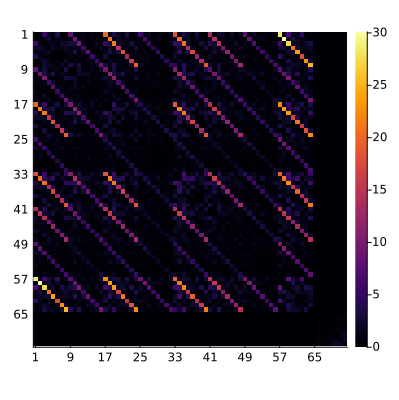

In [12]:
# stateCLL = leftcanonical(stateCLL, true)
_, M = eigen(stateLL.Rs[1][]);
P = projection_matrix(D, M)

Q = P[1:D^2, D^2+1:end]
Qn = Matrix(qr(Q).Q)
Pn = copy(P)
Pn[1:D^2, D^2+1:end] .= Qn / sqrt(2)
Pn[D^2+1:end, D^2+1:end] .= -Qn / sqrt(2)
Pn = Matrix(qr(P).Q);

ρR = rightenv(stateCLL)[1][]
ρR ./= tr(ρR)
B = left2centre_matrix(ρR)
#B = centre2left_matrix(ρR)'

#B = Matrix(I, size(B))

space = InfiniteCMPSExcitationSpace(0, stateCLL, stateCLL)
Heff = excitation_matrix(excitation_operator(HCLL, space), D);
res = round.(Pn' * B' * Heff * B * Pn, digits=1)

heatmap(abs.(res .- Diagonal(res)), yflip=true, aspect_ratio=1, size=(400, 400), xticks=1:D:D^2+D, yticks=1:D:D^2+D)

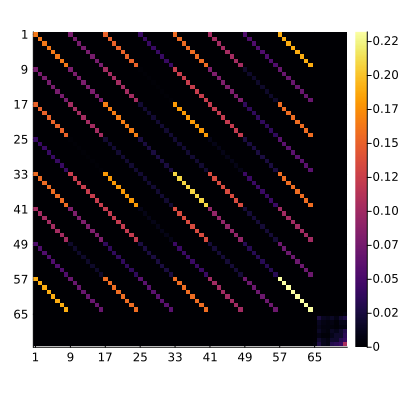

In [13]:
heatmap(abs.(Pn' * B' * B * Pn), yflip=true, aspect_ratio=1, size=(400, 400), xticks=1:D:D^2+D, yticks=1:D:D^2+D)

In [14]:
ρ = real(expval(ψ̂₁' * ψ̂₁ + ψ̂₂' * ψ̂₂, stateCLL)[]);
ps = range(0, 2π * ρ, 10)

spectrum_even = zeros(length(ps), D^2)
spectrum_odd = zeros(length(ps), D)
Threads.@threads for idx in eachindex(ps)
    space = InfiniteCMPSExcitationSpace(ps[idx], stateCLL, stateCLL)
    Heff = excitation_matrix(excitation_operator(HCLL, space), D)
    Hc = Pn' * B' * Heff * B * Pn

    spectrum_even[idx, :] .= real.(eigen(Hc[1:D^2, 1:D^2]).values)
    spectrum_odd[idx, :] .= real.(eigen(Hc[D^2+1:end, D^2+1:end]).values)
end

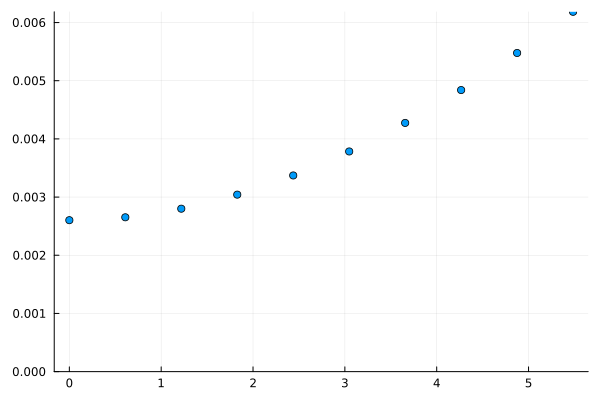

In [15]:
scatter(ps, spectrum_odd[:, 1], lab = "", ylims = [0, Inf])

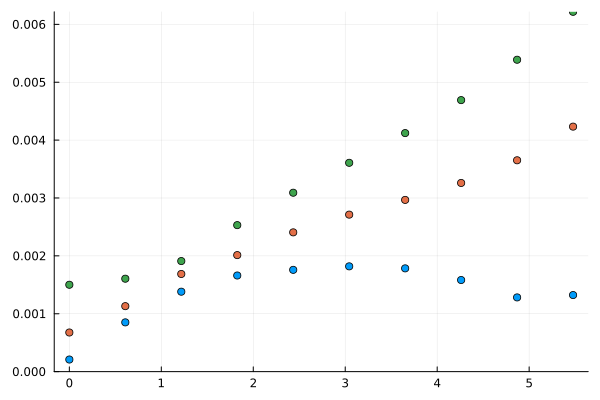

In [64]:
scatter(ps, spectrum_even[:, 1:3], lab = "", ylims = [0, Inf])

### Explicitly constructing goldstone modes

In [16]:
function leftgaugetv(Q, R, V, W1, W2, p)
    # assuming Q, R are in cMPS left gauge
    X, _ = linsolve(-R' * (W1 + W2) - V) do X
        (Q * X - X * Q) + 1im * p * X + 2 * R' * (R * X - X * R)
    end

    return V + (Q * X - X * Q) + 1im * p * X, W1 + (R * X - X * R), W2 + (R * X - X * R)
end

Q, R = stateCLL.Q[], stateCLL.Rs[1][];
ρR = rightenv(stateCLL)[1][];

pgs = range(0, 5., 20)
energies = zeros(ComplexF64, length(pgs))
ρR = rightenv(stateCLL)[1][];
ρR ./= tr(ρR)

Threads.@threads for idx in eachindex(pgs)
    V, W1, W2 = zero(Q), R, -R
    V, W1, W2 = leftgaugetv(Q, R, V, W1, W2, pgs[idx])

    # ∫⟨H⟩ - ⟨H₀⟩ = E -> intensive contribution to energy on top of extensive ground state energy
    space = InfiniteCMPSExcitationSpace(pgs[idx], stateCLL, stateCLL)
    Heff = excitation_operator(HCLL, space)
    P = projection_matrix(D, eigen(R).vectors)
    Hm = excitation_matrix(Heff, D)

    res = P * P' * Hm * P * P' * vcat(vec(W1), vec(W2))
    HW1f = reshape(view(res, 1:D^2), D, D)
    HW2f = reshape(view(res, D^2+1:2*D^2), D, D)

    energies[idx] = tr(HW1f * ρR * W1' + HW2f * ρR * W2') / tr(W1 * ρR * W1' + W2 * ρR * W2')
end

energies

20-element Vector{ComplexF64}:
  28.46855611750327 + 3.9778381092509204e-14im
 28.537808195065633 - 0.012498582392254317im
  28.74556442775262 - 0.024997164784544133im
  29.09182481556428 - 0.037495747176841177im
 29.576589358500488 - 0.049994329569131364im
  30.19985805656152 - 0.062492911961425826im
 30.961630909747107 - 0.07499149435372604im
 31.861907918057348 - 0.08749007674601272im
  32.90068908149217 - 0.09998865913831076im
  34.07797440005179 - 0.11248724153060258im
  35.39376387373599 - 0.12498582392287876im
  36.84805750254489 - 0.13748440631518766im
  38.44085528647842 - 0.14998298870748192im
   40.1721572255366 - 0.16248157109977301im
 42.041963319719414 - 0.17498015349205182im
 44.050273569026835 - 0.18747873588435823im
    46.197087973459 - 0.1999773182766501im
  48.48240653301579 - 0.2124759006689451im
  50.90622924769726 - 0.22497448306123266im
  53.46855611750337 - 0.23747306545353553im

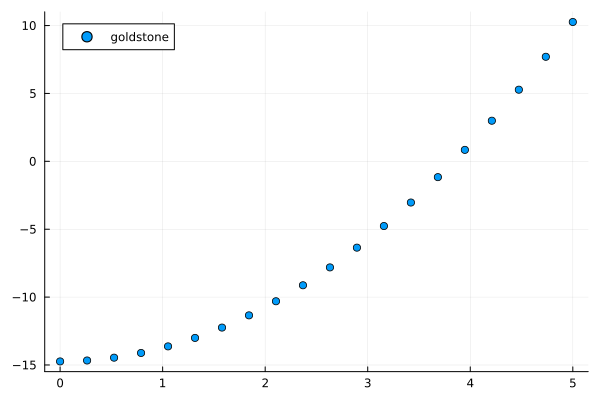

In [33]:
scatter(pgs, real.(energies), lab="goldstone")
#scatter!(ps, spectrum_odd[:, 1], lab="odd", ylim=[0, Inf])